In [16]:
import os
import matplotlib.pyplot as plt
import numpy as np

In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\shafeenausman\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


In [18]:
import os

train_dir = r"C:\Users\shafeenausman\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_train\seg_train"
test_dir  = r"C:\Users\shafeenausman\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test\seg_test"

classes = os.listdir(train_dir)
print("Classes:", classes)
print("Number of classes:", len(classes))


Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


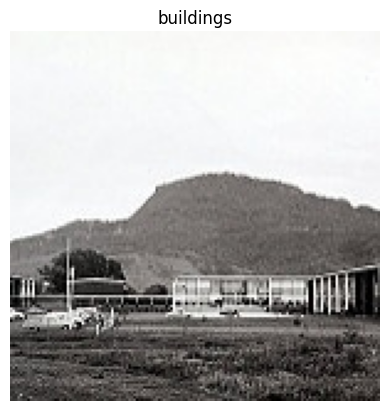

In [19]:
from tensorflow.keras.preprocessing.image import load_img

img_path = os.path.join(train_dir, classes[0], os.listdir(os.path.join(train_dir, classes[0]))[0])
img = load_img(img_path)

plt.imshow(img)
plt.axis('off')
plt.title(classes[0])
plt.show()


In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (150, 150)
batch_size = 32


In [21]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)


In [22]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [23]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [25]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])


C:\Users\shafeenausman\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [28]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [29]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("cnn_intel_model.h5", save_best_only=True)
]


In [30]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3936 - loss: 1.4738

351/351 ━━━━━━━━━━━━━━━━━━━━ 417s 1s/step - accuracy: 0.4896 - loss: 1.2687 - val_accuracy: 0.6209 - val_loss: 0.9991
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.6000 - loss: 1.0389

351/351 ━━━━━━━━━━━━━━━━━━━━ 220s 627ms/step - accuracy: 0.6078 - loss: 1.0260 - val_accuracy: 0.6837 - val_loss: 0.8471
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.6444 - loss: 0.9450

351/351 ━━━━━━━━━━━━━━━━━━━━ 237s 675ms/step - accuracy: 0.6502 - loss: 0.9298 - val_accuracy: 0.7126 - val_loss: 0.8049
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.6797 - loss: 0.8827

351/351 ━━━━━━━━━━━━━━━━━━━━ 197s 562ms/step - accuracy: 0.6881 - loss: 0.8623 - val_accuracy: 0.7111 - val_loss: 0.7750
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.7016 - loss: 0.8174

...

351/351 ━━━━━━━━━━━━━━━━━━━━ 180s 513ms/step - accuracy: 0.7386 - loss: 0.7283 - val_accuracy: 0.7807 - val_loss: 0.6210
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.7532 - loss: 0.7191

351/351 ━━━━━━━━━━━━━━━━━━━━ 180s 514ms/step - accuracy: 0.7508 - loss: 0.7043 - val_accuracy: 0.7932 - val_loss: 0.6026
Epoch 9/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.7515 - loss: 0.6842

351/351 ━━━━━━━━━━━━━━━━━━━━ 180s 512ms/step - accuracy: 0.7544 - loss: 0.6817 - val_accuracy: 0.7789 - val_loss: 0.5945
Epoch 10/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 1912s 5s/step - accuracy: 0.7664 - loss: 0.6503 - val_accuracy: 0.7810 - val_loss: 0.6103
Epoch 11/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 315s 789ms/step - accuracy: 0.7705 - loss: 0.6553 - val_accuracy: 0.7864 - val_loss: 0.5986
Epoch 12/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.7843 - loss: 0.6130

351/351 ━━━━━━━━━━━━━━━━━━━━ 269s 765ms/step - accuracy: 0.7846 - loss: 0.6097 - val_accuracy: 0.8039 - val_loss: 0.5409
Epoch 13/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 716ms/step - accuracy: 0.7888 - loss: 0.5934

351/351 ━━━━━━━━━━━━━━━━━━━━ 278s 791ms/step - accuracy: 0.7860 - loss: 0.6011 - val_accuracy: 0.8238 - val_loss: 0.5083
Epoch 14/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 241s 686ms/step - accuracy: 0.7931 - loss: 0.5848 - val_accuracy: 0.8063 - val_loss: 0.5423
Epoch 15/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 229s 652ms/step - accuracy: 0.7947 - loss: 0.5823 - val_accuracy: 0.8078 - val_loss: 0.5433
Epoch 16/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 224s 636ms/step - accuracy: 0.7988 - loss: 0.5733 - val_accuracy: 0.8124 - val_loss: 0.5511
Epoch 17/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 224s 638ms/step - accuracy: 0.8106 - loss: 0.5510 - val_accuracy: 0.8053 - val_loss: 0.5603
Epoch 18/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 242s 689ms/step - accuracy: 0.8070 - loss: 0.5434 - val_accuracy: 0.8053 - val_loss: 0.5444


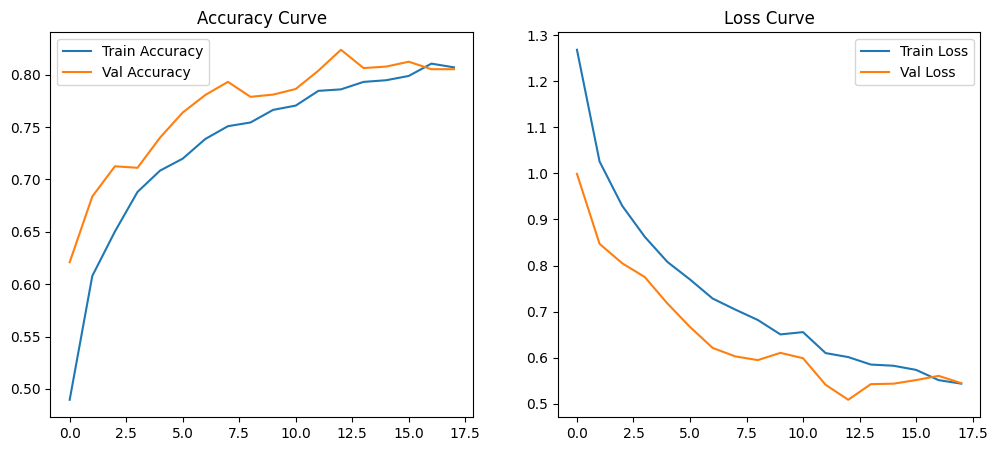

In [31]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")

plt.show()


In [32]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)


94/94 ━━━━━━━━━━━━━━━━━━━━ 43s 456ms/step - accuracy: 0.8333 - loss: 0.4862
Test Accuracy: 0.8333333134651184


In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [34]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())


94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step


In [35]:
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


              precision    recall  f1-score   support

   buildings       0.77      0.83      0.80       437
      forest       0.95      0.98      0.97       474
     glacier       0.81      0.76      0.79       553
    mountain       0.80      0.77      0.79       525
         sea       0.84      0.80      0.82       510
      street       0.83      0.88      0.85       501

    accuracy                           0.83      3000
   macro avg       0.83      0.84      0.83      3000
weighted avg       0.83      0.83      0.83      3000



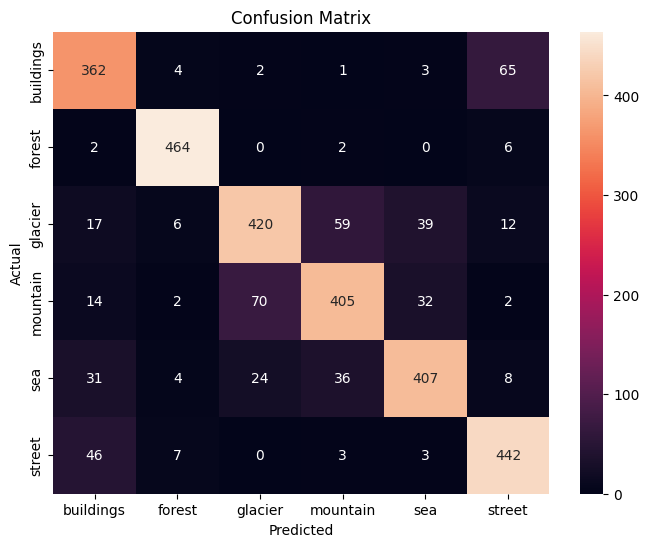

In [36]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [37]:
import random


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


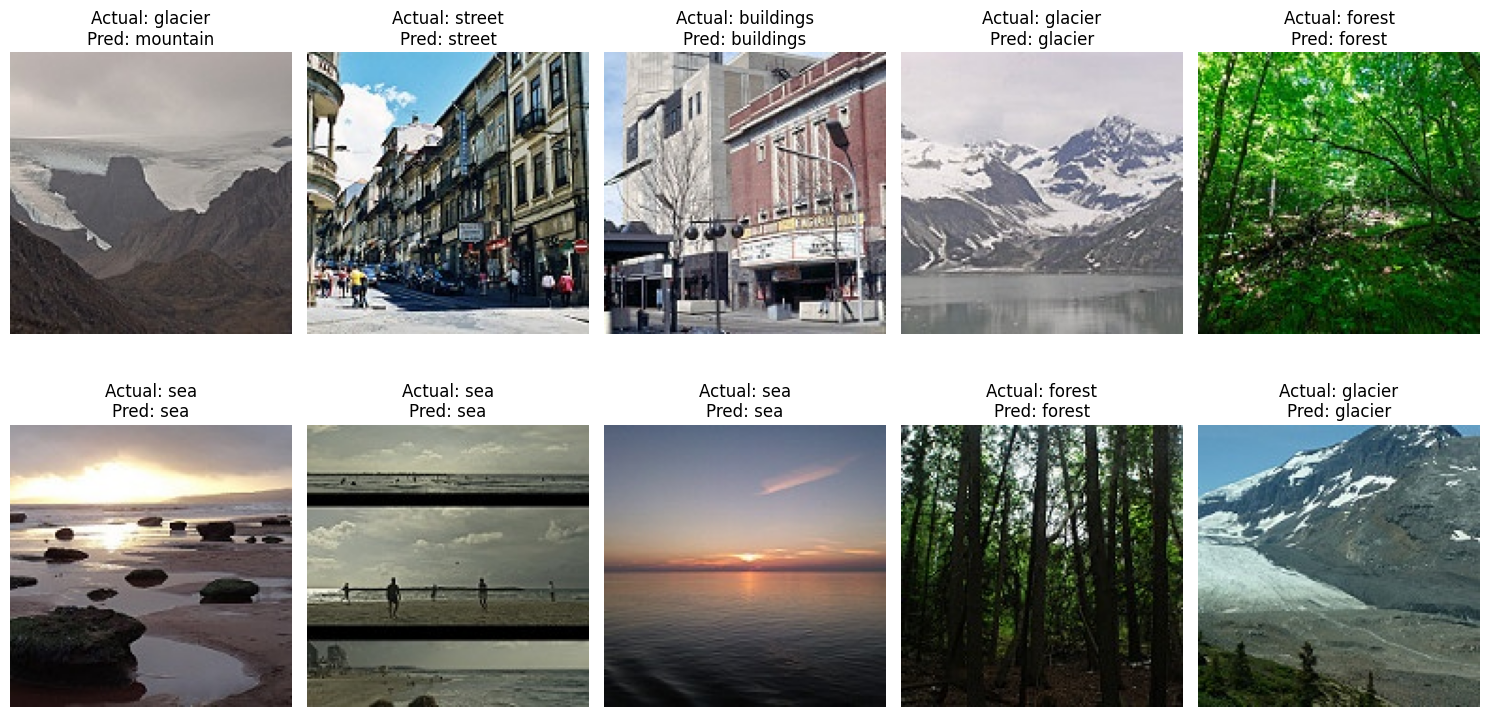

In [39]:
import random
import matplotlib.pyplot as plt
import numpy as np

class_labels = list(test_generator.class_indices.keys())

plt.figure(figsize=(15, 8))

for i in range(10):
    # pick a random batch
    batch_idx = random.randint(0, len(test_generator) - 1)
    images, labels = test_generator[batch_idx]

    # pick a random image from batch
    img_idx = random.randint(0, images.shape[0] - 1)

    img = images[img_idx]
    true_label = class_labels[np.argmax(labels[img_idx])]

    pred = model.predict(img[np.newaxis, ...])
    pred_label = class_labels[np.argmax(pred)]

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Actual: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()
